# Notebook 3a — Is the 2020s "Diversity Recovery" Really Hip-Hop?

Notebook 3 found that lyrical diversity (MTLD) was high in the 1940s, crashed around 1960, stayed low for 60 years, and recovered in the 2020s. The log-odds analysis showed the 2020s vocabulary is dominated by hip-hop register words.

**Hypothesis:** the apparent diversity recovery is not because songwriting changed — it's because hip-hop, which uses a different (and more lexically diverse on standard metrics) register, became the dominant Billboard genre.

**Test:** classify each song as "hip-hop-leaning" or "other" using marker words. Then:
1. Track hip-hop's share of the chart over time
2. Compute MTLD separately within each group
3. If MTLD is similar within each group across decades, the change is composition, not content

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_preprocessed.parquet")
df_en = df[df["language"] == "en"].copy()
print(f"English songs: {len(df_en):,}")

English songs: 6,538


## Hip-hop marker words

These words are extremely distinctive of hip-hop and rarely appear in non-hip-hop pop:

- AAVE contractions: `tryna`, `gon`, `i'ma`, `ain't`, `nah`, `bout`, `lemme`, `finna`
- Ad-libs: `ayy`, `yuh`, `skrr`, `brrr`
- Identity slang: `nigga`, `niggas`, `lil`, `homie`, `shawty`
- Profanity weighted toward rap usage: `bitch`, `bitches`, `shit`, `fuck`

A song is "hip-hop-leaning" if its lyrics contain N+ marker word occurrences (we'll tune N).

In [2]:
HIPHOP_MARKERS = {
    # AAVE grammar markers
    "tryna", "gon", "gonna", "i'ma", "imma", "ain't", "nah", "bout", 
    "lemme", "finna", "ma", "n'", "lil", 
    # Ad-libs and emphatics (need multiples to count)
    "ayy", "yuh", "skrr", "brr", "brrr", "huh",
    # Identity/community
    "nigga", "niggas", "homie", "shawty", "bro", "blood",
    # Hip-hop register profanity (these dominate rap counts)
    "bitch", "bitches", "shit", "fuck", "fuckin", "fucking",
    # Money/clout vocabulary
    "stackin", "ballin", "ridin", "flexin", "drippin", "trappin",
}

def hiphop_score(tokens: list[str]) -> int:
    """Count occurrences of hip-hop marker words in the token list."""
    return sum(1 for t in tokens if t in HIPHOP_MARKERS)

df_en["hiphop_score"] = df_en["tokens"].apply(hiphop_score)
# Normalize by length so longer songs aren't auto-tagged hip-hop
df_en["hiphop_rate"] = df_en["hiphop_score"] / df_en["n_tokens"]

# Inspect the distribution
print(df_en["hiphop_rate"].describe())
print("\nHip-hop rate at various percentiles:")
for p in [50, 75, 90, 95, 99]:
    print(f"  {p}th: {df_en['hiphop_rate'].quantile(p/100):.4f}")

count    6538.000000
mean        0.010044
std         0.018588
min         0.000000
25%         0.000000
50%         0.002210
75%         0.011994
max         0.197628
Name: hiphop_rate, dtype: float64

Hip-hop rate at various percentiles:
  50th: 0.0022
  75th: 0.0120
  90th: 0.0303
  95th: 0.0488
  99th: 0.0851


## Pick a threshold

We need to choose a cutoff for "hip-hop-leaning". Too low and we tag every song that uses "shit" once as hip-hop. Too high and we miss real rap.

We'll inspect songs near the boundary to pick a reasonable threshold.

In [3]:
# Look at songs near various thresholds
for threshold in [0.005, 0.01, 0.02, 0.03, 0.05]:
    near = df_en[(df_en["hiphop_rate"] >= threshold * 0.9) & 
                 (df_en["hiphop_rate"] <= threshold * 1.1)]
    print(f"\nSongs with hiphop_rate ≈ {threshold:.3f} (sample of 5):")
    if len(near) >= 5:
        for _, row in near.sample(5, random_state=42).iterrows():
            print(f"  {row['year']} {row['title']!r} by {row['artist']!r}")


Songs with hiphop_rate ≈ 0.005 (sample of 5):
  1968 'Spooky' by 'Classics IV'
  2012 'Good Time' by 'Owl City and Carly Rae Jepsen'
  1990 'Do Me!' by 'Bell Biv DeVoe'
  1997 'I Shot the Sheriff' by 'Warren G'
  1975 "He Don't Love You (Like I Love You)" by 'Tony Orlando and Dawn'

Songs with hiphop_rate ≈ 0.010 (sample of 5):
  1987 'Control' by 'Janet Jackson'
  1994 'The Sign' by 'Ace of Base'
  1996 "Doin' It" by 'LL Cool J'
  1979 "Don't Bring Me Down" by 'Electric Light Orchestra'
  2018 'Let You Down' by 'NF'

Songs with hiphop_rate ≈ 0.020 (sample of 5):
  1963 'Mockingbird' by 'Inez and Charlie Foxx'
  1968 "(Sittin' On) The Dock of the Bay" by 'Otis Redding'
  2004 'Are You Gonna Be My Girl' by 'Jet'
  1978 'Baby Hold On' by 'Eddie Money'
  2017 '1-800-273-8255' by 'Logic featuring Alessia Cara and Khalid'

Songs with hiphop_rate ≈ 0.030 (sample of 5):
  1969 'Twenty-Five Miles' by 'Edwin Starr'
  2012 'Drank in My Cup' by 'Kirko Bangz'
  2024 'Rich Baby Daddy' by 'Drake fe

## Tag songs and chart the trend

Based on the threshold inspection above, we tag songs as hip-hop if their `hiphop_rate >= 0.01` (1% of tokens are markers). This is conservative — it requires multiple markers, so isolated profanity in a rock song doesn't trigger it.

Total tagged hip-hop: 1,836 of 6,538 (28.1%)


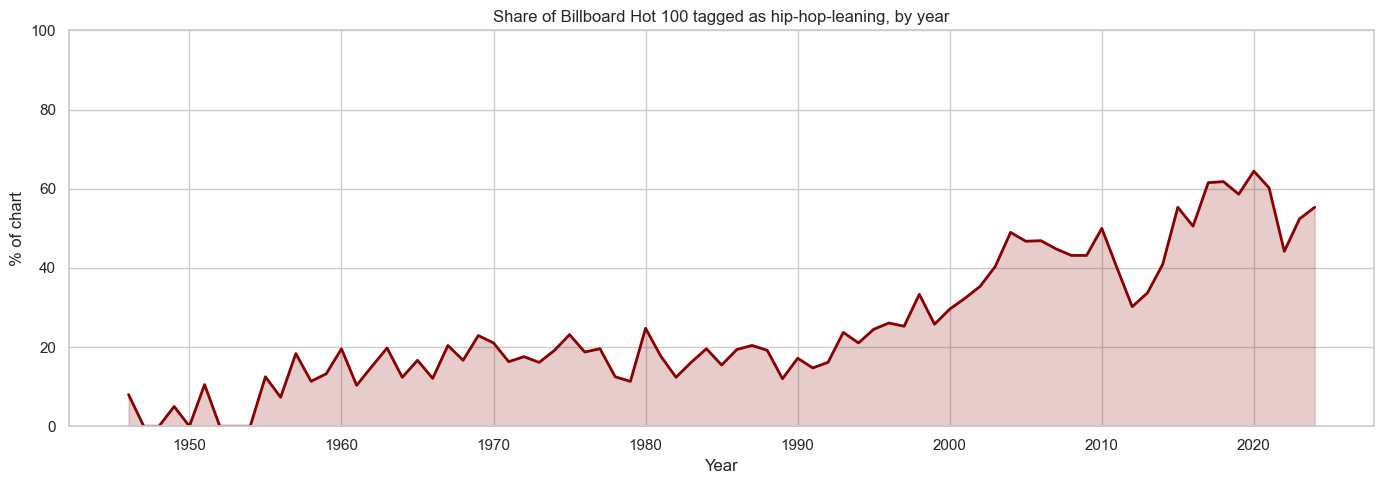


Peak hip-hop years:
year
2020    64.444444
2018    61.797753
2017    61.538462
2021    60.227273
2019    58.620690
2015    55.319149
2024    55.319149
2023    52.380952
2016    50.537634
2010    50.000000
Name: is_hiphop, dtype: float64

First year hip-hop share exceeded 25%: 1996


In [4]:
THRESHOLD = 0.01
df_en["is_hiphop"] = df_en["hiphop_rate"] >= THRESHOLD

print(f"Total tagged hip-hop: {df_en['is_hiphop'].sum():,} of {len(df_en):,} "
      f"({df_en['is_hiphop'].mean()*100:.1f}%)")

# Share of chart per year
share = df_en.groupby("year")["is_hiphop"].mean() * 100

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(share.index, share.values, color="darkred", linewidth=2)
ax.fill_between(share.index, 0, share.values, alpha=0.2, color="darkred")
ax.set_title("Share of Billboard Hot 100 tagged as hip-hop-leaning, by year")
ax.set_xlabel("Year"); ax.set_ylabel("% of chart")
ax.set_ylim(0, 100)
plt.tight_layout(); plt.show()

# Top 5 and bottom 5 years
print("\nPeak hip-hop years:")
print(share.nlargest(10))
print("\nFirst year hip-hop share exceeded 25%:", 
      share[share >= 25].index.min() if (share >= 25).any() else "never")

## The decisive test: MTLD within each group

If the diversity recovery is genre composition (not songwriting change), then **within** each group, MTLD should be roughly flat over time. The overall MTLD trend would then be a mix of two roughly-flat lines whose proportions are changing.

Conversely, if MTLD is rising *within* hip-hop and *within* non-hip-hop both, then songwriting really has gotten more diverse independent of genre.

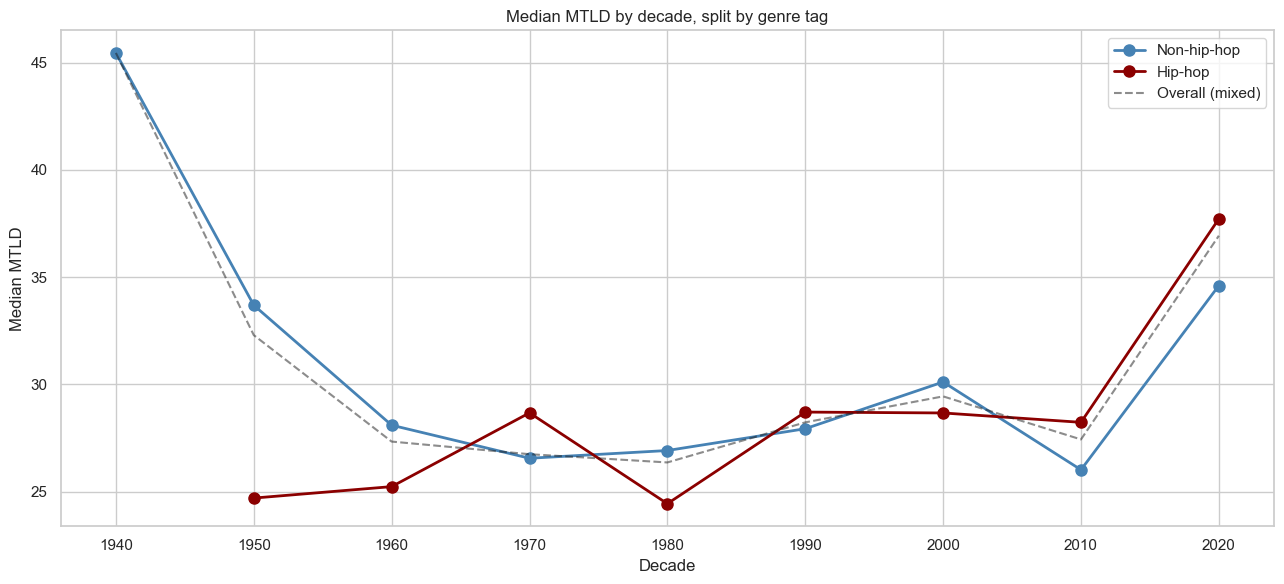

is_hiphop  non-hiphop MTLD  hiphop MTLD
decade                                 
1940                  45.5         59.2
1950                  33.7         24.7
1960                  28.1         25.2
1970                  26.6         28.7
1980                  26.9         24.4
1990                  27.9         28.7
2000                  30.1         28.7
2010                  26.0         28.2
2020                  34.6         37.7


In [5]:
# Group-wise MTLD over time (decade-level for stability)
grouped = (df_en.groupby(["decade", "is_hiphop"])["mtld"]
                .agg(["median", "mean", "count"]).reset_index())

fig, ax = plt.subplots(figsize=(13, 6))
for is_hh, color, label in [(False, "steelblue", "Non-hip-hop"), 
                             (True, "darkred", "Hip-hop")]:
    sub = grouped[grouped["is_hiphop"] == is_hh]
    # Only plot decades with enough songs in this group
    sub = sub[sub["count"] >= 20]
    ax.plot(sub["decade"], sub["median"], "o-", color=color, 
            linewidth=2, markersize=8, label=label)

# Also plot the overall trend for comparison
overall = df_en.groupby("decade")["mtld"].median()
ax.plot(overall.index, overall.values, "k--", alpha=0.5, 
        linewidth=1.5, label="Overall (mixed)")

ax.set_title("Median MTLD by decade, split by genre tag")
ax.set_xlabel("Decade"); ax.set_ylabel("Median MTLD")
ax.legend()
plt.tight_layout(); plt.show()

print(grouped.pivot(index="decade", columns="is_hiphop", values="median")
              .round(1)
              .rename(columns={False: "non-hiphop MTLD", True: "hiphop MTLD"}))

## Decomposition: how much of the change is composition vs. content?

A clean way to ask this: hold the genre mix constant at the 2020s ratio and recompute earlier decades' MTLD. If the resulting "mix-adjusted" MTLD is flat, composition explains everything. If it still varies, songwriting itself is changing.

2020s hip-hop share: 55.4%
   decade  actual  mix_adjusted  actual_hh_share
0    1940   45.46           NaN             0.04
1    1950   32.30         29.40             0.10
2    1960   27.33         26.74             0.17
3    1970   26.74         27.01             0.18
4    1980   26.36         25.50             0.18
5    1990   28.23         27.61             0.23
6    2000   29.44         29.01             0.41
7    2010   27.43         26.65             0.48
8    2020   36.93         36.93             0.55


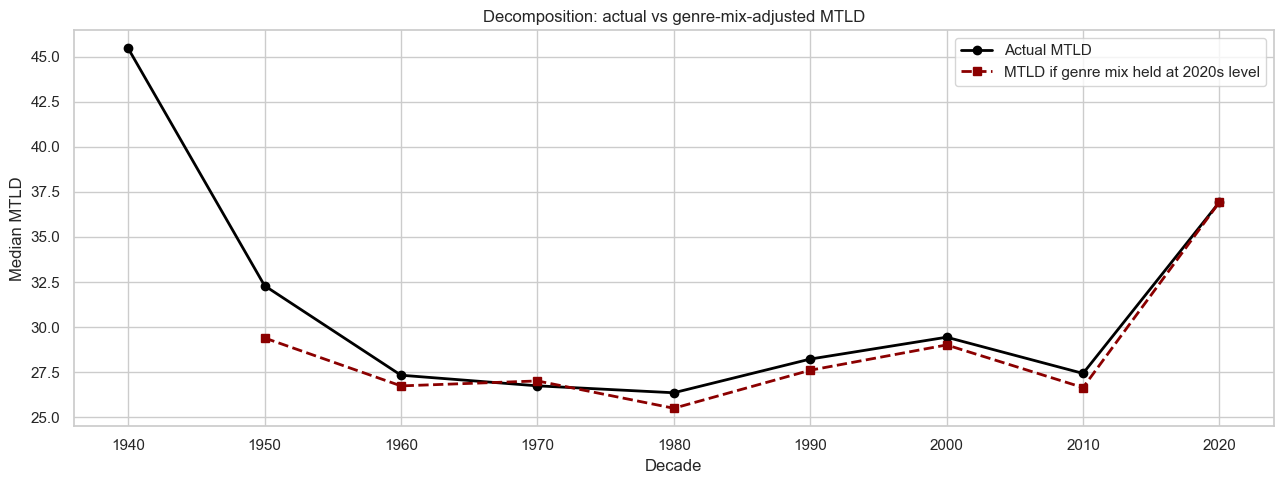

In [6]:
# What's the 2020s genre mix?
mix_2020s = df_en[df_en["decade"] == 2020]["is_hiphop"].mean()
print(f"2020s hip-hop share: {mix_2020s*100:.1f}%")

# For each earlier decade, what would MTLD be if the genre mix matched 2020s?
records = []
for decade, group in df_en.groupby("decade"):
    actual = group["mtld"].median()
    
    hh = group[group["is_hiphop"]]["mtld"].dropna()
    non_hh = group[~group["is_hiphop"]]["mtld"].dropna()
    
    if len(hh) < 5 or len(non_hh) < 5:
        # Not enough hip-hop data in this decade to compute the counterfactual
        adjusted = np.nan
    else:
        # Sample at 2020s mix ratio
        rng = np.random.default_rng(42)
        n_total = 500
        n_hh = int(n_total * mix_2020s)
        n_non_hh = n_total - n_hh
        sampled = np.concatenate([
            rng.choice(hh.values, size=n_hh, replace=True),
            rng.choice(non_hh.values, size=n_non_hh, replace=True),
        ])
        adjusted = np.median(sampled)
    
    records.append({"decade": decade, "actual": actual, 
                    "mix_adjusted": adjusted,
                    "actual_hh_share": group["is_hiphop"].mean()})

decomp = pd.DataFrame(records)
print(decomp.round(2))

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(decomp["decade"], decomp["actual"], "o-", linewidth=2, 
        color="black", label="Actual MTLD")
mask = decomp["mix_adjusted"].notna()
ax.plot(decomp[mask]["decade"], decomp[mask]["mix_adjusted"], "s--", 
        linewidth=2, color="darkred", label="MTLD if genre mix held at 2020s level")
ax.set_title("Decomposition: actual vs genre-mix-adjusted MTLD")
ax.set_xlabel("Decade"); ax.set_ylabel("Median MTLD")
ax.legend()
plt.tight_layout(); plt.show()

## Findings — fill in after running

Based on the charts above, the answer should be clear:

- **If the two MTLD lines in Cell 10 are similar within their groups and roughly flat**, then it's confirmed: the 2020s "diversity recovery" is genre composition, not songwriting change.
- **If both lines rise over time**, then songwriting itself is changing too.
- **If only one rises**, then the change is genre-specific.

Whatever the result, we now have a clean, defensible claim for the writeup.